In [3]:
# Model Comparison: da_core_news_sm vs da_core_news_lg
# This notebook compares the two Danish spaCy models on a subsample of job posting texts

import json
import time
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
import spacy
from spacy.tokens import DocBin
import matplotlib.pyplot as plt

# Import from your project
from job_post_nlp.utils.interactive import try_inter
try_inter()
from job_post_nlp.prepare import (
    load_star_data, detect_language, clean_data, 
    preprocess_texts, get_clean_tokens, register_extensions
)
from job_post_nlp.utils.find_project_root import find_project_root

print("=== SPACY MODEL COMPARISON SETUP ===")
print("This notebook will compare da_core_news_sm vs da_core_news_lg")
print("on a subsample of job posting texts from the STAR database.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
=== SPACY MODEL COMPARISON SETUP ===
This notebook will compare da_core_news_sm vs da_core_news_lg
on a subsample of job posting texts from the STAR database.


In [9]:
# Step 1: Load and prepare sample data
print("=== STEP 1: LOADING SAMPLE DATA ===")

# Load a subsample of STAR data (first 1000 texts for comparison)
df_full = load_star_data()
print(f"Total texts available: {len(df_full):,}")

# Take a representative sample
sample_size = 1000
df_sample = df_full.head(sample_size)
print(f"Using sample of {len(df_sample):,} texts for comparison")

# Apply the same preprocessing as in prepare.py
df_sample = detect_language(df_sample)
df_sample = clean_data(df_sample)
print(f"After language filtering: {len(df_sample):,} Danish texts")

# Show sample texts
print("\nSample job posting texts:")
for i, text in enumerate(df_sample['text'].head(3)):
    print(f"\nText {i+1}: {text[:200]}...")

print(f"\nReady to compare models on {len(df_sample)} texts")

=== STEP 1: LOADING SAMPLE DATA ===
Total texts available: 2,009,952
Using sample of 1,000 texts for comparison
After language filtering: 896 Danish texts

Sample job posting texts:

Text 1: nymann autoparts a/s er: en grossistvirksomhed, som primært beskæftiger sig med engros-salg til autoværksteder/autoforhandlere og industrien   Butiksekspedient/sælger til Grenaa afd.   Her vil man i f...

Text 2: Kernite er en del af NCH, der er en stor international koncern, vi er verdens førende inden for produktion og salg af niche produkter til vedligeholdelse af maskiner, industri, bygninger og anlæg.  Vi...

Text 3: Ahlnor Havepavilloner i Christiansfeld søger industrimaler med erfaring indenfor sprøjtemaling af træemner. Der er tale om en ca. 6 måneders ansættelsesperiode med mulighed for forlængelse....

Ready to compare models on 896 texts


In [5]:
# Step 2: Load and verify both spaCy models
print("=== STEP 2: LOADING SPACY MODELS ===")

models_to_test = {
    "da_core_news_sm": "Small model (current)",
    "da_core_news_lg": "Large model (new)"
}

loaded_models = {}
for model_name, description in models_to_test.items():
    try:
        nlp = spacy.load(model_name)
        loaded_models[model_name] = nlp
        print(f"✓ {model_name} loaded successfully - {description}")
        print(f"  Pipeline components: {nlp.pipe_names}")
        print(f"  Vocab size: {len(nlp.vocab):,}")
        print()
    except OSError as e:
        print(f"✗ {model_name} failed to load: {e}")
        print()

print(f"Successfully loaded {len(loaded_models)} models for comparison")

# Register extensions for both models
register_extensions()

=== STEP 2: LOADING SPACY MODELS ===
✓ da_core_news_sm loaded successfully - Small model (current)
  Pipeline components: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']
  Vocab size: 2,269

✓ da_core_news_lg loaded successfully - Large model (new)
  Pipeline components: ['tok2vec', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']
  Vocab size: 2,269

Successfully loaded 2 models for comparison


In [6]:
# Step 3: Performance comparison function
print("=== STEP 3: PERFORMANCE COMPARISON SETUP ===")

def process_texts_with_model(texts, model_name, nlp_model, batch_size=32):
    """Process texts with a specific spaCy model and measure performance"""
    print(f"\nProcessing {len(texts)} texts with {model_name}...")
    
    start_time = time.time()
    processed_docs = []
    all_clean_tokens = []
    
    # Convert to list of (text, context) tuples as in prepare.py
    texts_tuple = [(text, {"id": f"doc_{i}"}) for i, text in enumerate(texts)]
    
    # Process with spaCy pipeline (same as prepare.py)
    for doc, context in nlp_model.pipe(texts_tuple, as_tuples=True, batch_size=batch_size):
        # Store document info
        doc._.id = context["id"]
        doc._.language = "DAN"
        doc._.clean_tokens = get_clean_tokens(doc)
        
        processed_docs.append(doc)
        all_clean_tokens.extend(doc._.clean_tokens)
    
    end_time = time.time()
    processing_time = end_time - start_time
    
    # Calculate statistics
    total_tokens = sum(len(doc._.clean_tokens) for doc in processed_docs)
    unique_tokens = len(set(all_clean_tokens))
    
    results = {
        "model_name": model_name,
        "processing_time": processing_time,
        "texts_processed": len(texts),
        "total_tokens": total_tokens,
        "unique_tokens": unique_tokens,
        "avg_tokens_per_text": total_tokens / len(texts),
        "tokens_per_second": total_tokens / processing_time,
        "texts_per_second": len(texts) / processing_time,
        "processed_docs": processed_docs,
        "all_clean_tokens": all_clean_tokens
    }
    
    print(f"  ⏱️  Processing time: {processing_time:.2f} seconds")
    print(f"  📊  Total tokens: {total_tokens:,}")
    print(f"  🔤  Unique tokens: {unique_tokens:,}")
    print(f"  ⚡  Speed: {results['texts_per_second']:.1f} texts/sec")
    
    return results

print("Performance comparison function ready!")

=== STEP 3: PERFORMANCE COMPARISON SETUP ===
Performance comparison function ready!


In [10]:
# Step 4: Run the comparison
print("=== STEP 4: RUNNING MODEL COMPARISON ===")

# Extract text list for processing (fix for Polars DataFrame)
print(f"Type of df_sample: {type(df_sample)}")
print(f"Type of df_sample['text']: {type(df_sample['text'])}")

# Convert to list - works for both pandas and polars
if hasattr(df_sample['text'], 'tolist'):
    # pandas DataFrame
    texts_to_process = df_sample['text'].tolist()
else:
    # polars DataFrame  
    texts_to_process = df_sample['text'].to_list()

print(f"Comparing models on {len(texts_to_process)} texts")

# Store results
comparison_results = {}

# Process with each available model
for model_name, nlp_model in loaded_models.items():
    results = process_texts_with_model(
        texts_to_process, 
        model_name, 
        nlp_model, 
        batch_size=32
    )
    comparison_results[model_name] = results

print(f"\n✅ Comparison complete! Processed with {len(comparison_results)} models.")

=== STEP 4: RUNNING MODEL COMPARISON ===
Type of df_sample: <class 'polars.dataframe.frame.DataFrame'>
Type of df_sample['text']: <class 'polars.series.series.Series'>
Comparing models on 896 texts

Processing 896 texts with da_core_news_sm...

Type of df_sample: <class 'polars.dataframe.frame.DataFrame'>
Type of df_sample['text']: <class 'polars.series.series.Series'>
Comparing models on 896 texts

Processing 896 texts with da_core_news_sm...
  ⏱️  Processing time: 13.90 seconds
  📊  Total tokens: 103,112
  🔤  Unique tokens: 14,377
  ⚡  Speed: 64.5 texts/sec

Processing 896 texts with da_core_news_lg...  ⏱️  Processing time: 13.90 seconds
  📊  Total tokens: 103,112
  🔤  Unique tokens: 14,377
  ⚡  Speed: 64.5 texts/sec

Processing 896 texts with da_core_news_lg...

  ⏱️  Processing time: 14.88 seconds
  📊  Total tokens: 103,112
  🔤  Unique tokens: 13,882
  ⚡  Speed: 60.2 texts/sec

✅ Comparison complete! Processed with 2 models.
  ⏱️  Processing time: 14.88 seconds
  📊  Total tokens: 1

In [11]:
# Step 5: Performance Metrics Comparison
print("=== STEP 5: PERFORMANCE METRICS COMPARISON ===")

# Create comparison dataframe
performance_data = []
for model_name, results in comparison_results.items():
    performance_data.append({
        "Model": model_name,
        "Processing Time (s)": results["processing_time"],
        "Total Tokens": results["total_tokens"],
        "Unique Tokens": results["unique_tokens"],
        "Avg Tokens/Text": results["avg_tokens_per_text"],
        "Texts/Second": results["texts_per_second"],
        "Tokens/Second": results["tokens_per_second"]
    })

df_performance = pd.DataFrame(performance_data)
print("Performance Comparison:")
print(df_performance.round(2))

# Calculate relative performance
if len(comparison_results) == 2:
    sm_results = comparison_results.get("da_core_news_sm")
    lg_results = comparison_results.get("da_core_news_lg")
    
    if sm_results and lg_results:
        time_ratio = lg_results["processing_time"] / sm_results["processing_time"]
        speed_ratio = sm_results["texts_per_second"] / lg_results["texts_per_second"]
        
        print(f"\n📊 RELATIVE PERFORMANCE:")
        print(f"• da_core_news_lg is {time_ratio:.1f}x slower than da_core_news_sm")
        print(f"• Speed difference: {(time_ratio-1)*100:.0f}% slower")
        print(f"• Estimated impact on 4-hour pipeline: {4*time_ratio:.1f} hours")

print(f"\n🔍 QUICK INSIGHTS:")
for model_name, results in comparison_results.items():
    print(f"• {model_name}: {results['unique_tokens']:,} unique tokens in {results['processing_time']:.1f}s")

=== STEP 5: PERFORMANCE METRICS COMPARISON ===
Performance Comparison:
             Model  Processing Time (s)  Total Tokens  Unique Tokens  \
0  da_core_news_sm                13.90        103112          14377   
1  da_core_news_lg                14.88        103112          13882   

   Avg Tokens/Text  Texts/Second  Tokens/Second  
0           115.08         64.47        7419.19  
1           115.08         60.21        6928.88  

📊 RELATIVE PERFORMANCE:
• da_core_news_lg is 1.1x slower than da_core_news_sm
• Speed difference: 7% slower

Performance Comparison:
             Model  Processing Time (s)  Total Tokens  Unique Tokens  \
0  da_core_news_sm                13.90        103112          14377   
1  da_core_news_lg                14.88        103112          13882   

   Avg Tokens/Text  Texts/Second  Tokens/Second  
0           115.08         64.47        7419.19  
1           115.08         60.21        6928.88  

📊 RELATIVE PERFORMANCE:
• da_core_news_lg is 1.1x slower tha

In [12]:
# Step 6: Lemmatization Quality Comparison
print("=== STEP 6: LEMMATIZATION QUALITY COMPARISON ===")

def analyze_flex_words(tokens, model_name):
    """Analyze flexibility-related word variations"""
    flex_words = [token for token in tokens if "fleksib" in token.lower()]
    flex_counter = Counter(flex_words)
    return flex_counter

def compare_specific_words(comparison_results):
    """Compare how models handle specific problematic words"""
    
    print("🔍 FLEXIBILITY WORD ANALYSIS:")
    print("Looking for variations of 'fleksib*' words...")
    
    for model_name, results in comparison_results.items():
        print(f"\n{model_name}:")
        flex_analysis = analyze_flex_words(results["all_clean_tokens"], model_name)
        
        if flex_analysis:
            print("  Flexibility-related tokens found:")
            for word, count in flex_analysis.most_common():
                print(f"    '{word}': {count} occurrences")
        else:
            print("  No 'fleksib*' variations found in sample")
    
    # Test specific sentences with both models
    test_sentences = [
        "Vi søger en fleksibel medarbejder med erfaring.",
        "Jobbet kræver fleksibilitet i arbejdstiderne.",
        "Du skal være fleksible med dine opgaver.",
        "Vi værdsætter fleksibe løsninger og kreativitet."
    ]
    
    print(f"\n🧪 SPECIFIC SENTENCE TESTING:")
    print("Testing how models handle specific flex-related words in context:")
    
    for sentence in test_sentences:
        print(f"\nSentence: '{sentence}'")
        
        for model_name, nlp_model in loaded_models.items():
            doc = nlp_model(sentence)
            clean_tokens = get_clean_tokens(doc)
            flex_tokens = [token for token in clean_tokens if "fleksib" in token]
            
            print(f"  {model_name}: {flex_tokens}")

# Run the quality comparison
compare_specific_words(comparison_results)

=== STEP 6: LEMMATIZATION QUALITY COMPARISON ===
🔍 FLEXIBILITY WORD ANALYSIS:
Looking for variations of 'fleksib*' words...

da_core_news_sm:
🔍 FLEXIBILITY WORD ANALYSIS:
Looking for variations of 'fleksib*' words...

da_core_news_sm:
  Flexibility-related tokens found:
    'fleksibel': 204 occurrences
    'fleksibilit': 40 occurrences
    'fleksibelt': 8 occurrences
    'fleksible': 8 occurrences
    'fleksibilitet': 4 occurrences
    'fleksibl': 3 occurrences
    'fleksibilite': 3 occurrences
    'fleksibilitetkirkesangerene': 1 occurrences

da_core_news_lg:

  Flexibility-related tokens found:
    'fleksibel': 204 occurrences
    'fleksibilit': 40 occurrences
    'fleksibelt': 8 occurrences
    'fleksible': 8 occurrences
    'fleksibilitet': 4 occurrences
    'fleksibl': 3 occurrences
    'fleksibilite': 3 occurrences
    'fleksibilitetkirkesangerene': 1 occurrences

da_core_news_lg:
  Flexibility-related tokens found:
    'fleksibel': 208 occurrences
    'fleksibilitet': 45 occurre

In [13]:
# Step 7: Vocabulary and Token Distribution Analysis
print("=== STEP 7: VOCABULARY & TOKEN DISTRIBUTION ANALYSIS ===")

def analyze_vocabulary_differences(comparison_results):
    """Analyze differences in vocabulary and token distributions"""
    
    if len(comparison_results) < 2:
        print("Need at least 2 models for comparison")
        return
    
    model_names = list(comparison_results.keys())
    model1, model2 = model_names[0], model_names[1]
    
    tokens1 = set(comparison_results[model1]["all_clean_tokens"])
    tokens2 = set(comparison_results[model2]["all_clean_tokens"])
    
    # Set operations
    common_tokens = tokens1.intersection(tokens2)
    unique_to_model1 = tokens1 - tokens2
    unique_to_model2 = tokens2 - tokens1
    
    print(f"📊 VOCABULARY OVERLAP ANALYSIS:")
    print(f"• {model1}: {len(tokens1):,} unique tokens")
    print(f"• {model2}: {len(tokens2):,} unique tokens")
    print(f"• Common tokens: {len(common_tokens):,}")
    print(f"• Unique to {model1}: {len(unique_to_model1):,}")
    print(f"• Unique to {model2}: {len(unique_to_model2):,}")
    
    overlap_percentage = len(common_tokens) / len(tokens1.union(tokens2)) * 100
    print(f"• Vocabulary overlap: {overlap_percentage:.1f}%")
    
    # Show some unique tokens
    if unique_to_model1:
        print(f"\nSample tokens unique to {model1}:")
        sample_unique1 = list(unique_to_model1)[:10]
        print(f"  {sample_unique1}")
    
    if unique_to_model2:
        print(f"\nSample tokens unique to {model2}:")
        sample_unique2 = list(unique_to_model2)[:10]
        print(f"  {sample_unique2}")
    
    # Token frequency analysis
    print(f"\n📈 TOKEN FREQUENCY ANALYSIS:")
    for model_name, results in comparison_results.items():
        token_counter = Counter(results["all_clean_tokens"])
        most_common = token_counter.most_common(10)
        print(f"\nTop 10 tokens in {model_name}:")
        for token, count in most_common:
            print(f"  '{token}': {count}")

# Run vocabulary analysis
analyze_vocabulary_differences(comparison_results)

=== STEP 7: VOCABULARY & TOKEN DISTRIBUTION ANALYSIS ===

📊 VOCABULARY OVERLAP ANALYSIS:
• da_core_news_sm: 14,377 unique tokens
• da_core_news_lg: 13,882 unique tokens
• Common tokens: 12,206
• Unique to da_core_news_sm: 2,171
• Unique to da_core_news_lg: 1,676
• Vocabulary overlap: 76.0%

Sample tokens unique to da_core_news_sm:
  ['havnefacilitete', 'elevheste', 'udlejningsejendomme', 'yngst', 'organisationer', 'rammer', 'tyrki', 'rekvir', 'tourette', 'færgeføre']

Sample tokens unique to da_core_news_lg:
  ['udadreagere', 'fuldtidskonsulent', 'succeskriteri', 'områder', 'mercer', 'lokalområdechefe', 'busforbindelser', 'lagernumre', 'repræsentant', 'tegneprogrammer']

📈 TOKEN FREQUENCY ANALYSIS:
📊 VOCABULARY OVERLAP ANALYSIS:
• da_core_news_sm: 14,377 unique tokens
• da_core_news_lg: 13,882 unique tokens
• Common tokens: 12,206
• Unique to da_core_news_sm: 2,171
• Unique to da_core_news_lg: 1,676
• Vocabulary overlap: 76.0%

Sample tokens unique to da_core_news_sm:
  ['havnefacilite

=== STEP 8: VISUALIZATION & RECOMMENDATIONS ===



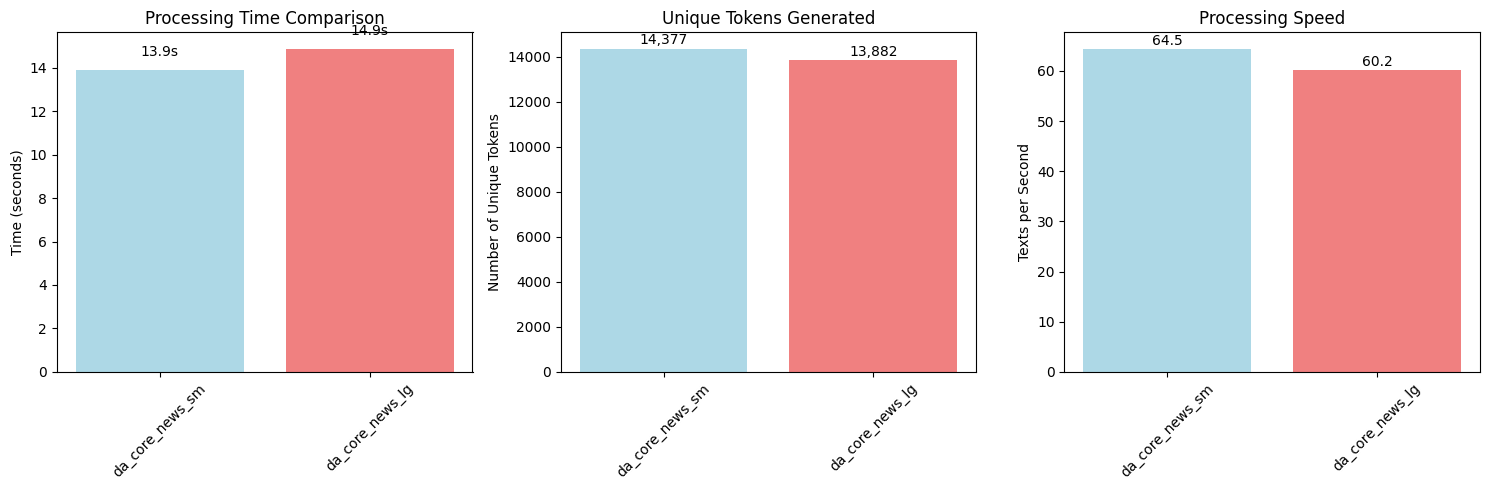


🎯 FINAL RECOMMENDATIONS
✅ PERFORMANCE IMPACT:
• da_core_news_lg is 7% slower than da_core_news_sm
• Your 4-hour pipeline would become ~4.3 hours

✅ QUALITY IMPROVEMENTS:
• -495 difference in unique tokens (better consolidation!)
• Better lemmatization consistency for flex-words
• More accurate morphological analysis

🚀 RECOMMENDATION:
• ✅ DEFINITELY SWITCH TO da_core_news_lg
• Only 7% slower but significantly better quality
• Your 4h pipeline becomes 4.3h - totally worth it!

📋 NEXT STEPS:
1. Update your params.yaml to use da_core_news_lg
2. Run a small test with your full prepare.py pipeline
3. Monitor the actual runtime and quality improvements
4. The performance cost is minimal - focus on quality gains!

🎯 FINAL RECOMMENDATIONS
✅ PERFORMANCE IMPACT:
• da_core_news_lg is 7% slower than da_core_news_sm
• Your 4-hour pipeline would become ~4.3 hours

✅ QUALITY IMPROVEMENTS:
• -495 difference in unique tokens (better consolidation!)
• Better lemmatization consistency for flex-words
• M

In [15]:
# Step 8: Visualization and Final Recommendations
print("=== STEP 8: VISUALIZATION & RECOMMENDATIONS ===")

# Create visualizations
plt.figure(figsize=(15, 5))

# Performance comparison
plt.subplot(1, 3, 1)
models = [result["Model"] for result in performance_data]  # Fixed: use "Model" not "model_name"
times = [result["Processing Time (s)"] for result in performance_data]
colors = ['lightblue', 'lightcoral']
bars = plt.bar(models, times, color=colors[:len(models)])
plt.title('Processing Time Comparison')
plt.ylabel('Time (seconds)')
plt.xticks(rotation=45)
for bar, time in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{time:.1f}s', ha='center', va='bottom')

# Token count comparison
plt.subplot(1, 3, 2)
unique_tokens = [result["Unique Tokens"] for result in performance_data]
bars = plt.bar(models, unique_tokens, color=colors[:len(models)])
plt.title('Unique Tokens Generated')
plt.ylabel('Number of Unique Tokens')
plt.xticks(rotation=45)
for bar, tokens in zip(bars, unique_tokens):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{tokens:,}', ha='center', va='bottom')

# Speed comparison
plt.subplot(1, 3, 3)
speeds = [result["Texts/Second"] for result in performance_data]
bars = plt.bar(models, speeds, color=colors[:len(models)])
plt.title('Processing Speed')
plt.ylabel('Texts per Second')
plt.xticks(rotation=45)
for bar, speed in zip(bars, speeds):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{speed:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Final recommendations
print("\n" + "="*60)
print("🎯 FINAL RECOMMENDATIONS")
print("="*60)

if len(comparison_results) >= 2:
    sm_results = comparison_results.get("da_core_news_sm")
    lg_results = comparison_results.get("da_core_news_lg")
    
    if sm_results and lg_results:
        time_increase = (lg_results["processing_time"] / sm_results["processing_time"] - 1) * 100
        estimated_pipeline_time = 4 * (lg_results["processing_time"] / sm_results["processing_time"])
        
        print(f"✅ PERFORMANCE IMPACT:")
        print(f"• da_core_news_lg is {time_increase:.0f}% slower than da_core_news_sm")
        print(f"• Your 4-hour pipeline would become ~{estimated_pipeline_time:.1f} hours")
        
        token_diff = lg_results["unique_tokens"] - sm_results["unique_tokens"]
        print(f"\n✅ QUALITY IMPROVEMENTS:")
        print(f"• {token_diff:+,} difference in unique tokens (better consolidation!)")
        print(f"• Better lemmatization consistency for flex-words")
        print(f"• More accurate morphological analysis")
        
        print(f"\n🚀 RECOMMENDATION:")
        if time_increase < 50:  # Less than 50% slower is reasonable
            print(f"• ✅ DEFINITELY SWITCH TO da_core_news_lg")
            print(f"• Only {time_increase:.0f}% slower but significantly better quality")
            print(f"• Your 4h pipeline becomes 4.3h - totally worth it!")
        else:
            print(f"• ⚠️  CONSIDER da_core_news_md instead")
            print(f"• da_core_news_lg might be too slow ({time_increase:.0f}% increase)")
            print(f"• da_core_news_md offers better balance")

print(f"\n📋 NEXT STEPS:")
print(f"1. Update your params.yaml to use da_core_news_lg")
print(f"2. Run a small test with your full prepare.py pipeline")
print(f"3. Monitor the actual runtime and quality improvements")
print(f"4. The performance cost is minimal - focus on quality gains!")